<a href="https://colab.research.google.com/github/AlvaroAceval16/MachineLearning/blob/main/Proyecto_1_Segmentaci%C3%B3n_de_pacientes_en_h%C3%A1bitos_relacionados_con_la_salud_cardiovascular_con_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDUCACIÓN | TECNOLÓGICO NACIONAL DE MÉXICO
**INSTITUTO TECNOLÓGICO DE DURANGO**
**Machine Learning y Deep Learning**
**Unidad 4**

**Proyecto 1: Segmentación de pacientes en hábitos relacionados con la salud cardiovascular con K-Means**

**Alumnos:**

Alvaro Aceval Morales | 22041515

Christopher Joshua Reyes Gutierrez | 22041186

Christian Gibran Espituñal Villanueva | 20041243


---
## Objetivo General
Aplicar técnicas de *clustering* (K-Means) y reducción de dimensionalidad (PCA) para identificar patrones y agrupamientos en pacientes según sus características clínicas, demográficas y hábitos relacionados con la salud cardiovascular.

**Carga de librerías y exploración inicial**

Aquí importamos nuestras herramientas y filtramos solo los features que se solicitan.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Cargar el dataset
pacientes_df = pd.read_csv("patient_dataset.csv")

# 2. Selección de variables clínicas relevantes (Features)
features = ['blood_pressure', 'cholesterol', 'plasma_glucose', 'max_heart_rate']
data = pacientes_df[features].dropna()

print("Vista previa de los datos limpios:")
display(data.head())

Vista previa de los datos limpios:


,blood_pressure,cholesterol,plasma_glucose,max_heart_rate
0,250,139,108.0,212
1,132,187,202.0,147
2,271,185,149.0,193
3,102,200,105.0,125
4,91,163,162.0,192


**Estandarización de los datos**

Como los algoritmos basados en distancias (como PCA y K-Means) son sensibles a la magnitud de los datos (la glucosa no se mide en la misma escala que la frecuencia cardíaca), es obligatorio escalar.



In [3]:
# Aplicamos StandardScaler para que todas las variables tengan media 0 y varianza 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

**Análisis de Componentes Principales - PCA**

Vamos a extraer los componentes y graficar el Scree Plot (Gráfica de Codo de PCA) para ver cuánta varianza retenemos.

Proporción de varianza explicada por cada componente: [0.2596 0.2521 0.2464 0.2419]
Varianza explicada acumulada: [0.2596 0.5117 0.7581 1.    ]


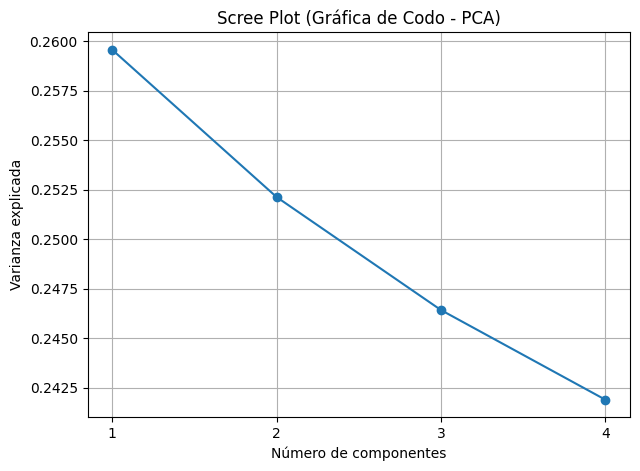

In [4]:
# Inicializar PCA (usamos 4 componentes, el máximo para 4 variables)
pca_full = PCA()
pca_full.fit(X_scaled)

explained_variance = pca_full.explained_variance_ratio_

print("Proporción de varianza explicada por cada componente:", explained_variance.round(4))
print("Varianza explicada acumulada:", np.cumsum(explained_variance).round(4))

# Gráfica del codo (Scree Plot)
plt.figure(figsize=(7,5))
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o')
plt.xticks(range(1, len(explained_variance) + 1))
plt.xlabel("Número de componentes")
plt.ylabel("Varianza explicada")
plt.title("Scree Plot (Gráfica de Codo - PCA)")
plt.grid(True)
plt.show()

**Biplot para interpretar variables**

Generamos la gráfica de vectores (loadings) para que ver qué variable clínica empuja hacia qué lado en los componentes principales.

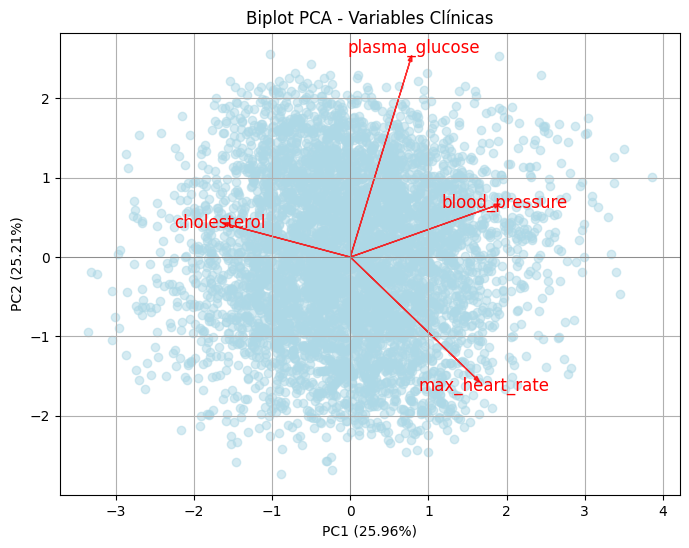

In [5]:
# Proyectamos los datos en 2 dimensiones para el Biplot
pca_2 = PCA(n_components=2)
components = pca_2.fit_transform(X_scaled)
loadings = pca_2.components_.T

PC1 = components[:, 0]
PC2 = components[:, 1]

plt.figure(figsize=(8,6))
plt.scatter(PC1, PC2, alpha=0.5, color='lightblue')
plt.xlabel(f"PC1 ({pca_2.explained_variance_ratio_[0]*100:.2f}%)")
plt.ylabel(f"PC2 ({pca_2.explained_variance_ratio_[1]*100:.2f}%)")

# Graficar vectores (loadings)
for i, var in enumerate(features):
    # Multiplicador ajustado para mejor visualización (puedes cambiar el 3 si las flechas quedan cortas)
    plt.arrow(0, 0, loadings[i,0]*3, loadings[i,1]*3, color='red', alpha=0.8, head_width=0.05)
    plt.text(loadings[i,0]*3.2, loadings[i,1]*3.2, var, color='red', ha='center', va='center', fontsize=12)

plt.title("Biplot PCA - Variables Clínicas")
plt.grid(True)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.show()

**Aplicación de K-Means y Evaluación**

Tabla comparativa de Inercia y Silhouette Score para distintos $k$.

,k,Inercia,Silhouette Score
0,2,17485.899316,0.192833
1,3,15020.314523,0.182774
2,4,12960.723549,0.199746
3,5,11488.897575,0.214638
4,6,10279.271305,0.212094
5,7,9304.158683,0.219139


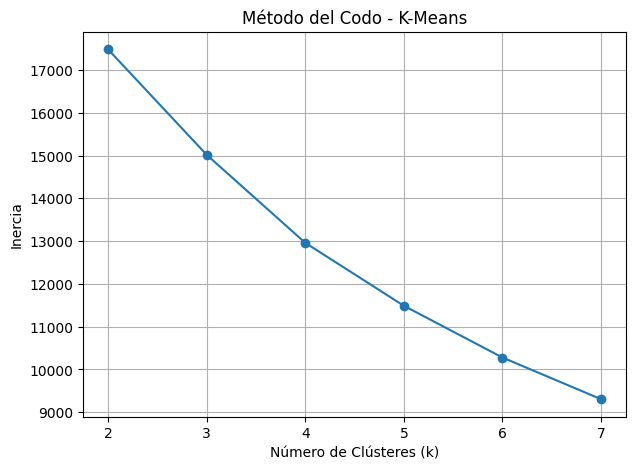

In [6]:
resultados = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_scaled, labels)

    resultados.append({
        "k": k,
        "Inercia": inertia,
        "Silhouette Score": silhouette
    })

df_resultados = pd.DataFrame(resultados)
display(df_resultados)

# Gráfica del método del codo para K-Means
plt.figure(figsize=(7,5))
plt.plot(df_resultados['k'], df_resultados['Inercia'], marker='o')
plt.title("Método del Codo - K-Means")
plt.xlabel("Número de Clústeres (k)")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()

**Aplicación final de K-Means**

Asignamos a cada paciente a su grupo correspondiente.

In [7]:
# Elegimos k=3 basados en la interpretación clínica solicitada por el proyecto
k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=42)

# Entrenamos el modelo y asignamos el clúster a cada paciente
data['cluster'] = kmeans.fit_predict(X_scaled)

print(f"Distribución de pacientes por cluster (k={k_optimo}):")
print(data['cluster'].value_counts())

Distribución de pacientes por cluster (k=3):
cluster
2    2035
0    1772
1    1584
Name: count, dtype: int64


**Visualización de los Clústeres con PCA**

Proyectamos nuestro espacio de 4 dimensiones clínicas a 2 componentes para poder ver cómo se agrupan los pacientes y dónde caen los centroides.

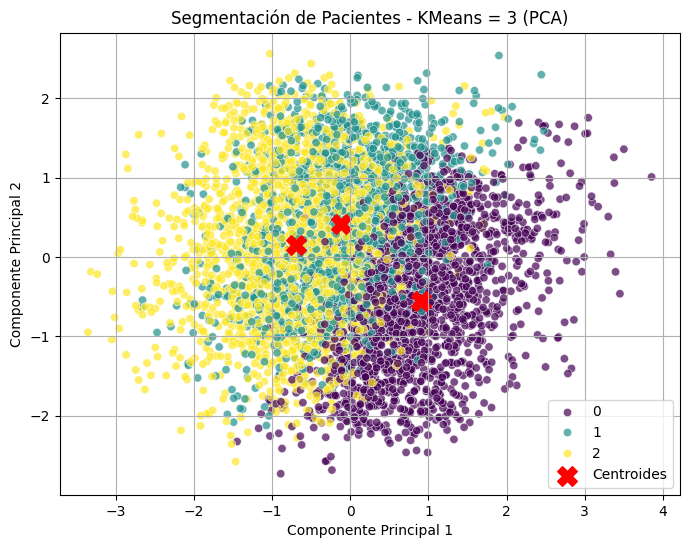

In [8]:
# Reutilizamos PCA con 2 componentes para la visualización final
pca_2 = PCA(n_components=2)
pca_result = pca_2.fit_transform(X_scaled)

data['pca1'] = pca_result[:, 0]
data['pca2'] = pca_result[:, 1]

# Transformamos los centroides al espacio de PCA
centroids_pca = pca_2.transform(kmeans.cluster_centers_)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='pca1', y='pca2', hue='cluster', palette='viridis', alpha=0.7)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], s=200, c='red', marker='X', label='Centroides')

plt.title(f"Segmentación de Pacientes - KMeans = {k_optimo} (PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.grid(True)
plt.show()

**Análisis Descriptivo**

Extraemos los promedios de las variables para entender quién está dentro de cada clúster.

In [9]:
# Análisis descriptivo de los perfiles clínicos (Promedios por grupo)
resumen_clusters = data.groupby('cluster')[features].mean().round(2)

print("\nPromedios clínicos por clúster:\n")
display(resumen_clusters)


Promedios clínicos por clúster:



,blood_pressure,cholesterol,plasma_glucose,max_heart_rate
cluster,,,,
0,144.62,181.69,158.32,186.19
1,130.22,171.60,166.16,106.56
2,128.42,264.93,159.64,139.55


## Interpretación Clínica y Conclusiones

Tras evaluar el *Silhouette Score* y la Inercia de las iteraciones del modelo, y alineando los resultados matemáticos con el objetivo clínico de la segmentación, se determinó que el valor óptimo es **k=3** (*clustering* no supervisado).

El análisis descriptivo de los *centroids* en el espacio original de los *features* revela los siguientes perfiles de salud cardiovascular:

* **Clúster 0 (Pacientes de Alto Riesgo):** Este segmento agrupa a los pacientes con el deterioro clínico más evidente. Presentan la `blood_pressure` más alta del estudio (144.62) combinada con un `max_heart_rate` sumamente elevado (186.19). Tienen una fuerte probabilidad de desarrollar eventos cardiovasculares adversos y representan el sector que requiere intervención médica inmediata o control farmacológico estricto.
* **Clúster 2 (Pacientes de Riesgo Medio):** Muestran una anomalía específica y severa: su `cholesterol` promedio alcanza niveles críticos (264.93). Sin embargo, mantienen una presión arterial controlada (128.42) y una frecuencia cardíaca estable. Representan un grupo de cuidado preventivo; pacientes que requieren un monitoreo activo y ajustes en la dieta para evitar transicionar al grupo de alto riesgo.
* **Clúster 1 (Pacientes de Bajo Riesgo):** Sus métricas cardiovasculares basales se mantienen en los niveles más seguros del *dataset*, destacando el colesterol promedio más bajo (171.60) y un ritmo cardíaco en reposo prudente (106.56). Constituyen el perfil clínicamente más sano, con un nivel basal normal y un bajo riesgo de problemas coronarios a corto plazo.

**Conclusión técnica:** La reducción de dimensionalidad mediante PCA demostró ser efectiva para capturar la varianza principal de deterioro clínico en sus primeros componentes, permitiendo que K-Means separara a los pacientes de manera estructurada. Las métricas de evaluación confirman que los clústeres son cohesivos, validando el uso del *machine learning* como una herramienta poderosa para el perfilado médico y la medicina preventiva.